In [1]:
pip install albumentations opencv-python -q


In [2]:
pip install ultralytics --q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 62.4 MB/s eta 0:00:00


In [3]:
import os, random, shutil, math
from glob import glob
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
import albumentations as A
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, Conv2DTranspose,
                                     Concatenate, BatchNormalization, Activation, Dropout)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

In [4]:
import kagglehub
path = kagglehub.dataset_download("imtkaggleteam/dental-radiography")
print("Path to dataset files:", path)

100%|██████████| 18.5M/18.5M [00:01<00:00, 9.87MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1


In [76]:
ROOT = "/root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1"
IMG_SIZE = (224, 224)
YOLO_IMG_SIZE = 640
BATCH_SIZE = 8
UNET_EPOCHS = 10
YOLO_EPOCHS = 50
MASKS_DIR = os.path.join(ROOT, "masks")
YOLO_DATA_DIR = os.path.join(ROOT, "yolo_data")


In [6]:
def load_annotations(split_dir):
    csv_path = os.path.join(split_dir, "_annotations.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"No annotation CSV at {csv_path}")
    df = pd.read_csv(csv_path)
    df['filepath'] = df['filename'].apply(lambda x: os.path.join(split_dir, x))
    for col in ['xmin','ymin','xmax','ymax']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)
    return df[['filepath','class','xmin','ymin','xmax','ymax']]

train_df = load_annotations(os.path.join(ROOT, "train"))
valid_df = load_annotations(os.path.join(ROOT, "valid"))
test_df  = load_annotations(os.path.join(ROOT, "test"))

print("Train:", len(train_df), "Val:", len(valid_df), "Test:", len(test_df))

Train: 8030 Val: 780 Test: 473


In [7]:
def create_masks_from_bboxes(df, out_dir, img_size=IMG_SIZE):
    os.makedirs(out_dir, exist_ok=True)
    for _, row in df.iterrows():
        src = row['filepath']
        if not os.path.exists(src):
            continue
        img = Image.open(src).convert("RGB")
        orig_w, orig_h = img.size
        scale_x = img_size[1] / orig_w
        scale_y = img_size[0] / orig_h
        xmin = int(row['xmin'] * scale_x)
        ymin = int(row['ymin'] * scale_y)
        xmax = int(row['xmax'] * scale_x)
        ymax = int(row['ymax'] * scale_y)
        xmin, ymin = max(0, xmin), max(0, ymin)
        xmax, ymax = min(img_size[1]-1, xmax), min(img_size[0]-1, ymax)
        mask = Image.new("L", (img_size[1], img_size[0]), 0)
        draw = ImageDraw.Draw(mask)
        if xmax > xmin and ymax > ymin:
            draw.rectangle([xmin, ymin, xmax, ymax], fill=255)
        base = os.path.basename(src)
        name, _ = os.path.splitext(base)
        out_path = os.path.join(out_dir, f"{name}_mask.png")
        mask.save(out_path)
    print("Masks saved to:", out_dir)

if not os.path.exists(MASKS_DIR) or len(os.listdir(MASKS_DIR)) < len(train_df)+len(valid_df)+len(test_df):
    create_masks_from_bboxes(pd.concat([train_df, valid_df, test_df], ignore_index=True), MASKS_DIR, IMG_SIZE)
else:
    print("Masks directory exists:", MASKS_DIR)

Masks saved to: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/masks


In [62]:
train_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.8),
    A.GaussNoise(var_limit=(10, 80), p=0.6),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8,8), p=0.6),
    A.RandomGamma(gamma_limit=(70,130), p=0.5),
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids']))

valid_transform = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids']))

/tmp/ipython-input-2623442754.py:3: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 80), p=0.6),


In [63]:
# Data generator for U-Net (applies transforms to image & bbox -> mask)
def unet_generator_from_df(df, masks_dir, transform, batch_size=BATCH_SIZE, shuffle=True):
    idxs = np.arange(len(df))
    while True:
        if shuffle:
            np.random.shuffle(idxs)
        for start in range(0, len(idxs), batch_size):
            end = start + batch_size
            if end > len(idxs):
                break
            batch_idxs = idxs[start:end]
            imgs = []
            masks = []
            for i in batch_idxs:
                row = df.iloc[i]
                img_path = row['filepath']
                base = os.path.basename(img_path)
                name, _ = os.path.splitext(base)
                mask_path = os.path.join(masks_dir, f"{name}_mask.png")
                image = cv2.imread(img_path)
                if image is None:
                    image = np.zeros((IMG_SIZE[0], IMG_SIZE[1], 3), dtype=np.uint8)
                h0, w0 = image.shape[:2]
                bbox = [row['xmin'], row['ymin'], row['xmax'], row['ymax']]
                try:
                    transformed = transform(image=image, bboxes=[bbox], category_ids=[0])
                    img_t = transformed['image']
                    bboxes_t = transformed['bboxes']
                except Exception as e:

                    image_rs = cv2.resize(image, (IMG_SIZE[1], IMG_SIZE[0]))
                    img_t = image_rs
                    scale_x = IMG_SIZE[1] / w0
                    scale_y = IMG_SIZE[0] / h0
                    bboxes_t = [[bbox[0]*scale_x, bbox[1]*scale_y, bbox[2]*scale_x, bbox[3]*scale_y]]
                mask = np.zeros((IMG_SIZE[0], IMG_SIZE[1]), dtype=np.uint8)
                if len(bboxes_t) > 0:
                    bb = bboxes_t[0]
                    x1,y1,x2,y2 = [int(max(0, min(v, IMG_SIZE[1]-1))) for v in bb[:4]]
                    if x2 > x1 and y2 > y1:
                        mask[y1:y2, x1:x2] = 255
                img_t = img_t.astype(np.float32) / 255.0
                mask = (mask.astype(np.float32) / 255.0)
                mask = mask[..., np.newaxis]
                imgs.append(img_t)
                masks.append(mask)
            yield np.stack(imgs, axis=0), np.stack(masks, axis=0)


In [64]:
# U-Net model builder (standard U-Net)
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x

In [65]:
def build_unet(input_shape=(*IMG_SIZE, 3), base_filters=32, dropout=0.1):
    inputs = Input(shape=input_shape)
    c1 = conv_block(inputs, base_filters)
    p1 = MaxPooling2D()(c1)
    c2 = conv_block(p1, base_filters*2)
    p2 = MaxPooling2D()(c2)
    c3 = conv_block(p2, base_filters*4)
    p3 = MaxPooling2D()(c3)
    c4 = conv_block(p3, base_filters*8)
    p4 = MaxPooling2D()(c4)
    bn = conv_block(p4, base_filters*16)
    if dropout:
        bn = Dropout(dropout)(bn)
    u1 = Conv2DTranspose(base_filters*8, 2, strides=2, padding='same')(bn)
    u1 = Concatenate()([u1, c4])
    c5 = conv_block(u1, base_filters*8)
    u2 = Conv2DTranspose(base_filters*4, 2, strides=2, padding='same')(c5)
    u2 = Concatenate()([u2, c3])
    c6 = conv_block(u2, base_filters*4)
    u3 = Conv2DTranspose(base_filters*2, 2, strides=2, padding='same')(c6)
    u3 = Concatenate()([u3, c2])
    c7 = conv_block(u3, base_filters*2)
    u4 = Conv2DTranspose(base_filters, 2, strides=2, padding='same')(c7)
    u4 = Concatenate()([u4, c1])
    c8 = conv_block(u4, base_filters)
    outputs = Conv2D(1, 1, activation='sigmoid')(c8)
    model = Model(inputs, outputs, name='U-Net')
    return model

In [66]:
# Build and compile U-Net
unet = build_unet(input_shape=(*IMG_SIZE,3), base_filters=32, dropout=0.1)
unet.compile(optimizer=Adam(1e-4), loss='binary_crossentropy', metrics=['accuracy'])
unet.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 224, 224,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 224, 224,  │      9,248 │ activation_18[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 224, 224,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 112, 112,  │          0 │ activation_19[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 112, 112,  │     36,928 │ activation_20[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 56, 56,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_23[0][0] 

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [67]:
train_gen = unet_generator_from_df(train_df, MASKS_DIR, train_transform, batch_size=BATCH_SIZE, shuffle=True)
val_gen   = unet_generator_from_df(valid_df, MASKS_DIR, valid_transform, batch_size=BATCH_SIZE, shuffle=False)

steps_per_epoch = max(1, len(train_df)//BATCH_SIZE)
val_steps = max(1, len(valid_df)//BATCH_SIZE)

In [68]:
callbacks = [
    ModelCheckpoint("unet_best.h5", save_best_only=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]

In [69]:
history = unet.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    epochs=UNET_EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9840 - loss: 0.1941

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 169s 143ms/step - accuracy: 0.9840 - loss: 0.1940 - val_accuracy: 0.9917 - val_loss: 0.0740 - learning_rate: 1.0000e-04
Epoch 2/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9916 - loss: 0.0658

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.9916 - loss: 0.0658 - val_accuracy: 0.9917 - val_loss: 0.0488 - learning_rate: 1.0000e-04
Epoch 3/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9916 - loss: 0.0465

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - accuracy: 0.9916 - loss: 0.0465 - val_accuracy: 0.9918 - val_loss: 0.0393 - learning_rate: 1.0000e-04
Epoch 4/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9916 - loss: 0.0393

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.9916 - loss: 0.0393 - val_accuracy: 0.9918 - val_loss: 0.0357 - learning_rate: 1.0000e-04
Epoch 5/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9916 - loss: 0.0361

...

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 141s 141ms/step - accuracy: 0.9916 - loss: 0.0343 - val_accuracy: 0.9917 - val_loss: 0.0323 - learning_rate: 1.0000e-04
Epoch 7/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9915 - loss: 0.0337

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 142s 141ms/step - accuracy: 0.9915 - loss: 0.0337 - val_accuracy: 0.9917 - val_loss: 0.0315 - learning_rate: 1.0000e-04
Epoch 8/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9915 - loss: 0.0331

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.9915 - loss: 0.0331 - val_accuracy: 0.9918 - val_loss: 0.0310 - learning_rate: 1.0000e-04
Epoch 9/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9916 - loss: 0.0326

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.9916 - loss: 0.0326 - val_accuracy: 0.9918 - val_loss: 0.0308 - learning_rate: 1.0000e-04
Epoch 10/10
1003/1003 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9916 - loss: 0.0323

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.9916 - loss: 0.0323 - val_accuracy: 0.9917 - val_loss: 0.0306 - learning_rate: 1.0000e-04


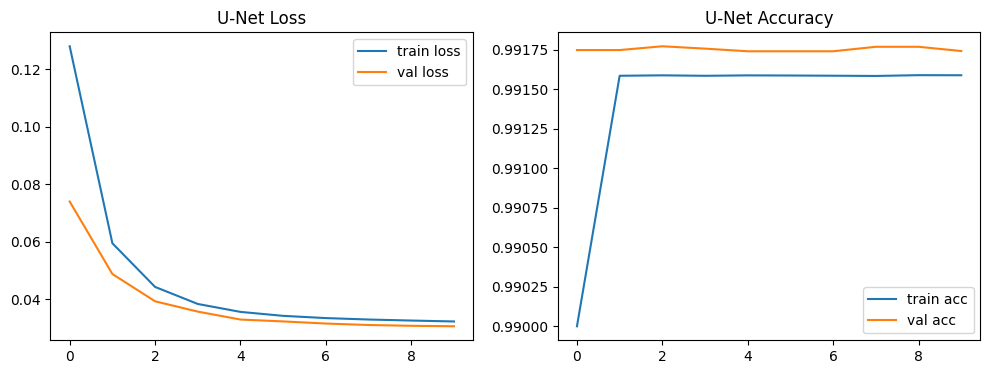

In [70]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title('U-Net Loss')
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title('U-Net Accuracy')
plt.show()

In [71]:
def iou_metric(y_true, y_pred, thresh=0.5):
    y_pred_bin = (y_pred > thresh).astype(np.uint8)
    y_true_bin = (y_true > 0.5).astype(np.uint8)
    inter = (y_pred_bin & y_true_bin).sum()
    union = (y_pred_bin | y_true_bin).sum()
    if union == 0:
        return 1.0 if inter == 0 else 0.0
    return inter / union

In [72]:
n_sample = min(20, len(valid_df))
sample_idxs = random.sample(range(len(valid_df)), n_sample)
ious = []
for idx in sample_idxs:
    row = valid_df.iloc[idx]
    img_path = row['filepath']
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE[::-1])
    arr = np.array(img, dtype=np.float32)/255.0
    pred = unet.predict(np.expand_dims(arr,0))[0,:,:,0]
    base = os.path.basename(img_path); name, _ = os.path.splitext(base)
    mask_path = os.path.join(MASKS_DIR, f"{name}_mask.png")
    if os.path.exists(mask_path):
        true_mask = np.array(Image.open(mask_path).convert('L').resize(IMG_SIZE[::-1]), dtype=np.float32)/255.0
    else:
        true_mask = np.zeros_like(pred)
    iou = iou_metric(true_mask, pred)
    ious.append(iou)
print("Mean IoU on sample validation subset:", np.mean(ious))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Mean IoU on sample validation subset: 0.0


In [73]:
try:
    from ultralytics import YOLO
    YOLO_AVAILABLE = True
except Exception:
    YOLO_AVAILABLE = False

In [77]:
# Prepare YOLO dataset

def prepare_yolo_dataset(train_df, valid_df, yolo_root=YOLO_DATA_DIR):

    CLASS_MAP = {
        'Cavity': 0,
        'Fillings': 1,
        'Impacted Tooth': 2,
        'Implant': 3
    }

    imgs_train = os.path.join(yolo_root, "images", "train")
    imgs_val   = os.path.join(yolo_root, "images", "val")
    labels_train = os.path.join(yolo_root, "labels", "train")
    labels_val   = os.path.join(yolo_root, "labels", "val")

    os.makedirs(imgs_train, exist_ok=True)
    os.makedirs(imgs_val, exist_ok=True)
    os.makedirs(labels_train, exist_ok=True)
    os.makedirs(labels_val, exist_ok=True)


    def prepare_split(df, imgs_dst, labels_dst):
      grouped = df.groupby('filepath')

      for img_path, rows in grouped:
          if not os.path.exists(img_path):
              continue

          base = os.path.basename(img_path)
          dst_img = os.path.join(imgs_dst, base)
          if not os.path.exists(dst_img):
              shutil.copy2(img_path, dst_img)

          img = Image.open(img_path)
          w, h = img.size

          lbl_path = os.path.join(labels_dst, os.path.splitext(base)[0] + ".txt")
          with open(lbl_path, "w") as f:
              for _, row in rows.iterrows():
                  cls_name = row['class']
                  if cls_name not in CLASS_MAP:
                      continue

                  xmin, ymin, xmax, ymax = row['xmin'], row['ymin'], row['xmax'], row['ymax']
                  x_center = ((xmin + xmax) / 2.0) / w
                  y_center = ((ymin + ymax) / 2.0) / h
                  width = (xmax - xmin) / w
                  height = (ymax - ymin) / h

                  cls = CLASS_MAP[cls_name]
                  f.write(f"{cls} {x_center} {y_center} {width} {height}\n")



    prepare_split(train_df, imgs_train, labels_train)
    prepare_split(valid_df, imgs_val, labels_val)

    data_yaml_path = os.path.join(yolo_root, "data.yaml")
    data_yaml = {
        'path': yolo_root,
        'train': 'images/train',
        'val': 'images/val',
        'nc': 4,
        'names': ['Cavity', 'Fillings', 'Impacted Tooth', 'Implant']
    }

    import yaml
    with open(data_yaml_path, "w") as f:
        yaml.dump(data_yaml, f)

    return data_yaml_path


In [78]:
CLASS_COLORS = {
    "Cavity": (255, 0, 0),
    "Filling": (0, 255, 0),
    "Impacted Tooth": (0, 0, 255),
    "Crown": (255, 255, 0)
}

In [79]:
yolo_model = None
if YOLO_AVAILABLE:
    print("Preparing YOLO dataset...")
    data_yaml = prepare_yolo_dataset(train_df, valid_df, YOLO_DATA_DIR)
    print("YOLO dataset prepared at:", YOLO_DATA_DIR)

    print("Training YOLO (this can take time).")
    yolo_model = YOLO('yolov8n.pt')
    yolo_model.train(
        data=data_yaml,
        epochs=YOLO_EPOCHS,
        imgsz=YOLO_IMG_SIZE
    )
else:
    print("Ultralytics YOLO not installed.")


Preparing YOLO dataset...
YOLO dataset prepared at: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/yolo_data
Training YOLO (this can take time).
Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max

In [80]:
def hybrid_inference(yolo_model, unet_model, image_path, conf_thresh=0.2, visualize=True):
    orig = cv2.imread(image_path)
    if orig is None:
        raise FileNotFoundError(image_path)

    h0, w0 = orig.shape[:2]
    canvas = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB).copy()


    if yolo_model is None:
        print("YOLO model not available. Skipping detection. Returning U-Net on full image.")

        img_rs = cv2.resize(canvas, (IMG_SIZE[1], IMG_SIZE[0]))
        pred_mask = unet_model.predict(
            np.expand_dims(img_rs.astype(np.float32) / 255.0, 0)
        )[0, :, :, 0]

        mask_bin = (pred_mask > 0.5).astype(np.uint8) * 255
        mask_resized = cv2.resize(mask_bin, (w0, h0))

        overlay = canvas.copy()
        overlay[:, :, 0] = np.where(mask_resized > 0, 255, overlay[:, :, 0])
        canvas = cv2.addWeighted(overlay, 0.5, canvas, 0.5, 0)

        if visualize:
            plt.figure(figsize=(8, 8))
            plt.imshow(canvas)
            plt.axis("off")
            plt.show()

        return canvas


    results = yolo_model(
        cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR),
        conf=conf_thresh,
        iou=0.5
    )[0]


    if results.boxes is None or len(results.boxes) == 0:
        print("No disease detected")
        if visualize:
            plt.figure(figsize=(8, 8))
            plt.imshow(canvas)
            plt.axis("off")
            plt.show()
        return canvas


    dets = []
    for box in results.boxes:
        conf = float(box.conf[0])
        cls_id = int(box.cls[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        dets.append((x1, y1, x2, y2, conf, cls_id))


    overlay = canvas.copy()


    for (x1, y1, x2, y2, conf, cls_id) in dets:
        x1 = max(0, min(w0 - 1, x1))
        x2 = max(0, min(w0 - 1, x2))
        y1 = max(0, min(h0 - 1, y1))
        y2 = max(0, min(h0 - 1, y2))
        if x2 <= x1 or y2 <= y1:
            continue

        label = yolo_model.names[cls_id]

        crop = canvas[y1:y2, x1:x2]
        crop_rs = cv2.resize(crop, (IMG_SIZE[1], IMG_SIZE[0]))

        pred = unet_model.predict(
            np.expand_dims(crop_rs.astype(np.float32) / 255.0, 0)
        )[0, :, :, 0]

        mask_bin = (pred > 0.5).astype(np.uint8) * 255
        mask_rs = cv2.resize(mask_bin, (x2 - x1, y2 - y1))

        # 🔹 Accumulate mask (do NOT overwrite)
        overlay[y1:y2, x1:x2, 0] = np.where(
            mask_rs > 0, 255, overlay[y1:y2, x1:x2, 0]
        )

        # 🔹 Always draw YOLO box & label
        cv2.rectangle(canvas, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            canvas,
            f"{label} | {conf:.2f}",
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 255, 255),
            1,
            cv2.LINE_AA,
        )


    canvas = cv2.addWeighted(overlay, 0.5, canvas, 0.5, 0)

    if visualize:
        plt.figure(figsize=(8, 8))
        plt.imshow(canvas)
        plt.axis("off")
        plt.show()

    return canvas


Image: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/test/0890_jpg.rf.63a002852dc3ca1c77006ac5c4421e90.jpg

0: 320x640 9 Fillingss, 5 Implants, 9.4ms
Speed: 1.6ms preprocess, 9.4ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

0: 320x640 9 Fillingss, 5 Implants, 7.8ms
Speed: 1.4ms preprocess, 7.8ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


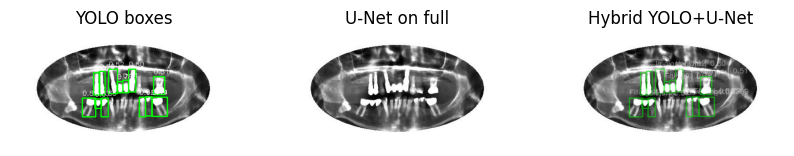

Image: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/test/0649_jpg.rf.b7d1c07a5deeb45e8fa8a2a076f504fd.jpg

0: 320x640 19 Fillingss, 4 Implants, 10.8ms
Speed: 2.2ms preprocess, 10.8ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

0: 320x640 19 Fillingss, 4 Implants, 6.6ms
Speed: 2.0ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━

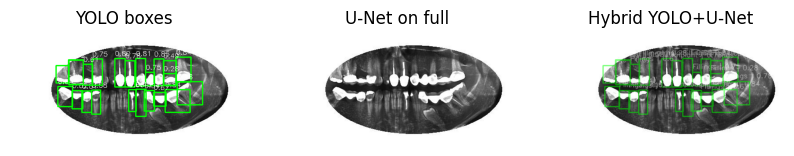

Image: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/test/0762_jpg.rf.65fd543f0d87cc9d38dc1968abb4d2c7.jpg

0: 320x640 6 Fillingss, 9 Implants, 10.5ms
Speed: 2.2ms preprocess, 10.5ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

0: 320x640 6 Fillingss, 9 Implants, 6.6ms
Speed: 2.8ms preprocess, 6.6ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━

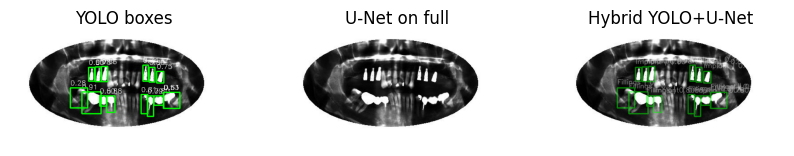

Image: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/test/0515_jpg.rf.8ff9c1348b7bbea5171159da2f241b71.jpg

0: 320x640 1 Cavity, 11 Fillingss, 9.0ms
Speed: 2.2ms preprocess, 9.0ms inference, 1.7ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

0: 320x640 1 Cavity, 11 Fillingss, 12.6ms
Speed: 1.7ms preprocess, 12.6ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


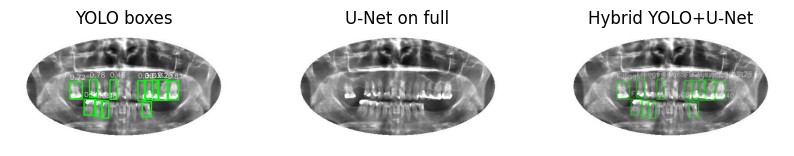

Image: /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/test/0564_jpg.rf.e086c7720a4a7be9d64b43c8588fd24a.jpg

0: 320x640 7 Fillingss, 11.6ms
Speed: 2.0ms preprocess, 11.6ms inference, 1.9ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

0: 320x640 7 Fillingss, 7.7ms
Speed: 2.0ms preprocess, 7.7ms inference, 1.3ms postprocess per image at shape (1, 3, 320, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


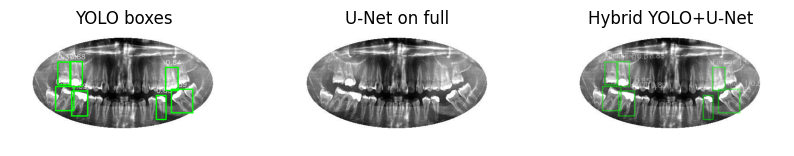

In [81]:
def show_examples(n=5):
    test_paths = test_df['filepath'].tolist()
    for i in range(n):
        p = random.choice(test_paths)
        print("Image:", p)
        if YOLO_AVAILABLE and yolo_model is not None:
            res = yolo_model(cv2.imread(p))[0]
            img_rgb = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
            for box in res.boxes:
                conf = float(box.conf[0])
                xy = box.xyxy[0].cpu().numpy().astype(int)
                x1,y1,x2,y2 = xy
                cv2.rectangle(img_rgb, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img_rgb, f"{conf:.2f}", (x1, y1-6), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)
            plt.figure(figsize=(10,4))
            plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('YOLO boxes'); plt.axis('off')
        else:
            plt.figure(figsize=(10,4))
            plt.subplot(1,3,1); plt.text(0.5,0.5,'YOLO not available',ha='center'); plt.axis('off')

        full = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        full_rs = cv2.resize(full, (IMG_SIZE[1], IMG_SIZE[0]))
        pred_mask = unet.predict(np.expand_dims(full_rs.astype(np.float32)/255.0,0))[0,:,:,0]
        mask_bin = (pred_mask>0.5).astype(np.uint8)*255
        mask_back = cv2.resize(mask_bin, (full.shape[1], full.shape[0]))
        overlay = full.copy()
        overlay[:,:,0] = np.where(mask_back>0, 255, overlay[:,:,0])
        blended = cv2.addWeighted(overlay, 0.5, full, 0.5, 0)
        plt.subplot(1,3,2); plt.imshow(blended); plt.title('U-Net on full'); plt.axis('off')

        hybrid = hybrid_inference(yolo_model, unet, p, conf_thresh=0.25, visualize=False)
        plt.subplot(1,3,3); plt.imshow(hybrid); plt.title('Hybrid YOLO+U-Net'); plt.axis('off')

        plt.show()

show_examples(n=5)

In [82]:
unet.save("unet_model.h5")
if YOLO_AVAILABLE and yolo_model is not None:
    yolo_model.save("yolo_model.pt")

print("Pipeline complete. U-Net saved to unet_model.h5; YOLO saved to yolo_model.pt (if trained).")


Pipeline complete. U-Net saved to unet_model.h5; YOLO saved to yolo_model.pt (if trained).


In [83]:
import cv2

def draw_yolo_predictions(image_path, model, conf=0.25):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(image_path, conf=conf)
    names = model.names

    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls_id = int(box.cls[0])
        confidence = float(box.conf[0])

        label = f"{names[cls_id]} {confidence:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(
            img,
            label,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

    return img



0: 352x640 5 Fillingss, 3 Impacted Tooths, 1 Implant, 19.5ms
Speed: 2.6ms preprocess, 19.5ms inference, 1.8ms postprocess per image at shape (1, 3, 352, 640)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


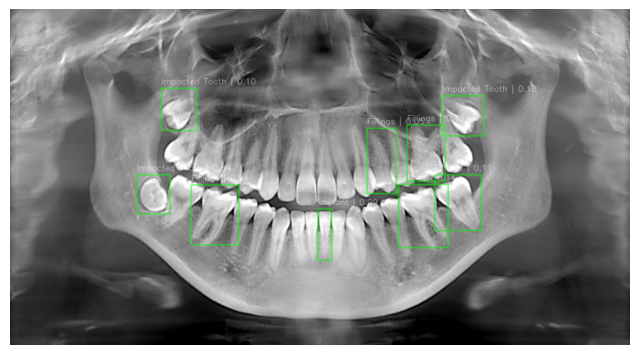

(np.float64(-0.5), np.float64(1160.5), np.float64(628.5), np.float64(-0.5))

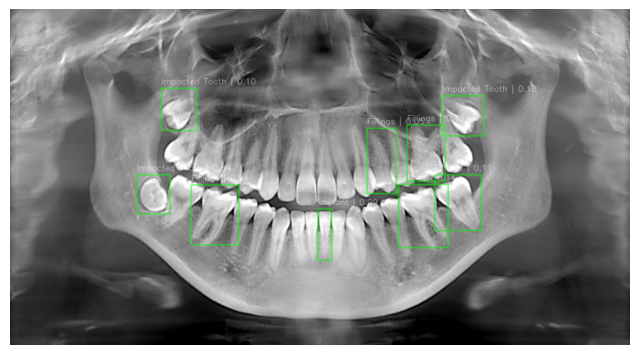

In [85]:
from ultralytics import YOLO
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt


model = YOLO("runs/detect/train/weights/best.pt")
unet_model = load_model("unet_model.h5", compile=False)

random_image = "/content/dental-x-ray-mesa-az.jpeg"

hybrid_img = hybrid_inference(
    yolo_model=model,
    unet_model=unet_model,
    image_path=random_image,
    conf_thresh=0.05
)

plt.figure(figsize=(8,8))
plt.imshow(hybrid_img)
plt.axis("off")


image 1/1 /root/.cache/kagglehub/datasets/imtkaggleteam/dental-radiography/versions/1/test/0298_jpg.rf.ecc80db88bce7954304f746c8536ad1f.jpg: 320x640 7 Fillingss, 2 Implants, 9.7ms
Speed: 2.4ms preprocess, 9.7ms inference, 1.4ms postprocess per image at shape (1, 3, 320, 640)


(np.float64(-0.5), np.float64(511.5), np.float64(255.5), np.float64(-0.5))

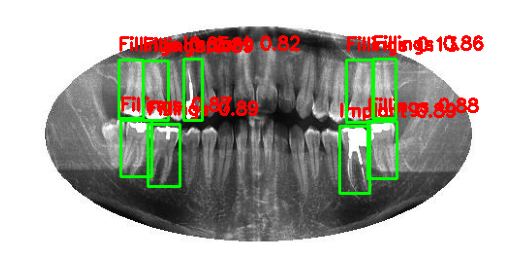

In [61]:
test_image = random.choice(test_df['filepath'].tolist())

img = draw_yolo_predictions(test_image, model, conf=0.1)
plt.imshow(img); plt.axis("off")
